Generates the plots and results for the paper: "LxCIM: a new rank-based binary classifier performance metric invariant to local exchange of classes"

In [1]:
import numpy as np
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt
from matplotlib.cm import ScalarMappable
from matplotlib.colors import LogNorm  # ✅ Correct import
from matplotlib import cm

from bicausal.metrics.drawers import plot_with_correctness, plot_both_with_correctness
from bicausal.metrics.lxcim import compute_lxcim
from bicausal.metrics.audrc import compute_audrc
from bicausal.metrics.evaluators import evaluate_tuebingen, construct_table
from bicausal.helpers.processers import process_tuebingen_scores
from bicausal.helpers.utils import save_imgs

all_methods=['ANM',"bQCD","CAM","CDCI","CDS","CGNN","FOM","HECI","IGCI","LCube","LOCI","NNCL","RECI","ROCHE","Slope","Sloppy"]

(<Figure size 600x600 with 2 Axes>,
 (<Axes: xlabel='Decision Rate', ylabel='Correct (1/0)'>,
  <Axes: title={'center': 'LXCIM - Tübingen'}, xlabel='Decision Rate', ylabel='Cumulative Accuracy'>))

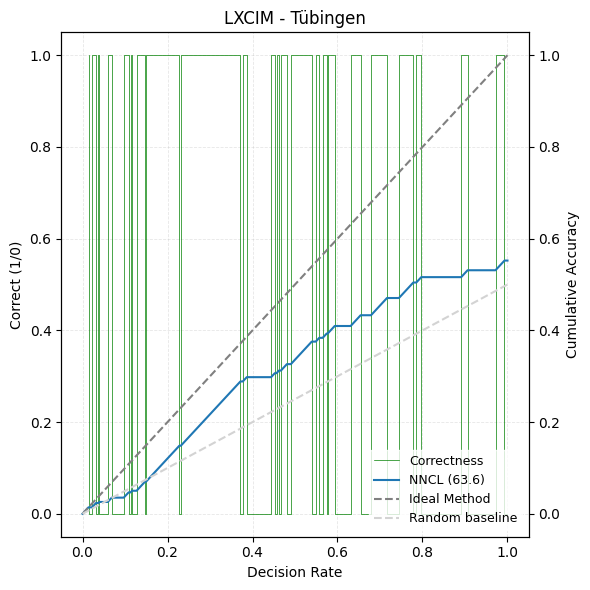

In [ ]:
#Figure 1: LxCIM NNCL performance on the Tuebingen dataset, with background correct and wrong guesses.
plot_with_correctness("NNCL","Tuebingen")

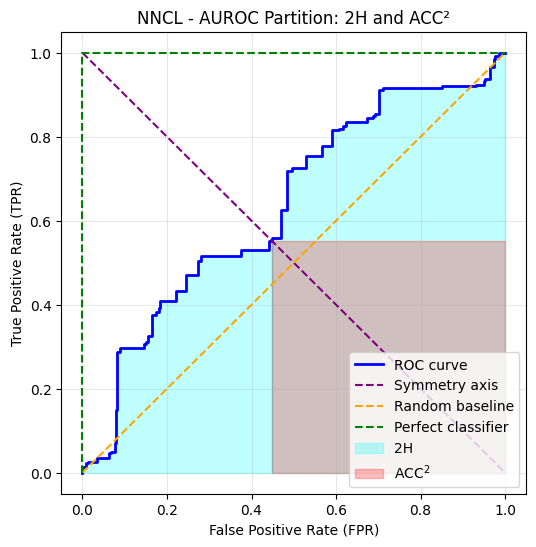

NNCL AUROC = 0.6356
Intersection at FPR=0.448, TPR=0.552


<Figure size 640x480 with 0 Axes>

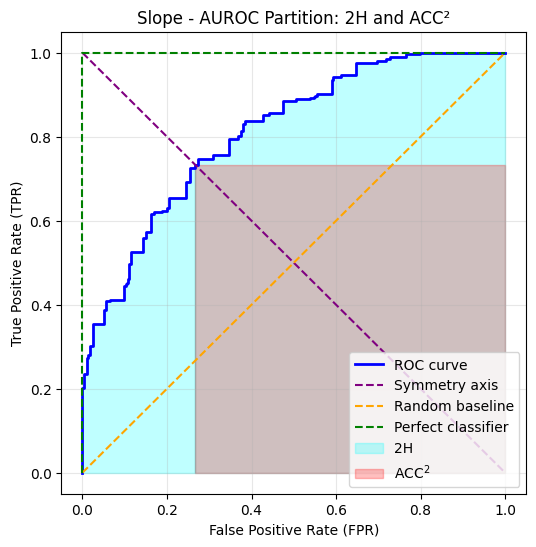

Slope AUROC = 0.8107
Intersection at FPR=0.267, TPR=0.733


<Figure size 640x480 with 0 Axes>

In [24]:
#Figure 2: The duplicated Tuebingen dataset AUROC curve for NNCL
methods=["NNCL","Slope"]
scores_path="results/tuebingen_scores.csv"
figsize=(6,6)


#code
methods_params, scores_list, original_weights = process_tuebingen_scores(
            methods=methods,
            scores_path=scores_path
        )


for method_param, scores in zip(methods_params, scores_list):
    meth_name, params = method_param
    method_label = meth_name if params == "" else f"{meth_name} ({params})"

    # --- Clean data ---
    mask = ~np.isnan(scores)
    scores, weights = scores[mask], original_weights[mask]

    # --- Construct y_true and weights for AUROC ---
    y_scores = np.concatenate((scores, -scores))
    y_true = np.concatenate((np.ones(len(scores)), np.zeros(len(scores))))
    w = np.concatenate((weights, weights))

    # --- Compute ROC and AUROC ---
    auroc = roc_auc_score(y_true, y_scores, sample_weight=w)
    fpr, tpr, _ = roc_curve(y_true, y_scores, sample_weight=w)

    # --- Find intersection with TPR = 1 - FPR ---
    diff = np.abs(tpr - (1 - fpr))
    idx_intersect = np.argmin(diff)
    fpr_i, tpr_i = fpr[idx_intersect], tpr[idx_intersect]

    # --- Plot ROC and AUROC regions ---
    plt.figure(figsize=figsize)
    plt.plot(fpr, tpr, color='blue', lw=2, label='ROC curve')
    plt.plot([0, 1], [1, 0], color='purple', linestyle='--', label='Symmetry axis')
    plt.plot([0, 1], [0, 1], color='orange', linestyle='--', label='Random baseline')
    plt.plot([0, 0, 1], [0, 1, 1], color='green', linestyle='--', label='Perfect classifier')

    # --- Define and fill regions ---
    mask_left = fpr <= fpr_i
    plt.fill_between(fpr[mask_left], 0, tpr[mask_left], color='cyan', alpha=0.25, label='2H')

    mask_right = fpr >= fpr_i
    plt.fill_between(fpr[mask_right], 0, tpr[mask_right], color='cyan', alpha=0.25)

    plt.fill_betweenx([0, tpr_i], fpr_i, 1, color='red', alpha=0.25, label=r'ACC$^2$')

    # --- Style ---
    plt.xlabel('False Positive Rate (FPR)')
    plt.ylabel('True Positive Rate (TPR)')
    plt.title(f'{method_label} - AUROC Partition: 2H and ACC²')
    plt.legend(loc='lower right')
    plt.grid(alpha=0.3)
    plt.show()

    print(f"{method_label} AUROC = {auroc:.4f}")
    print(f"Intersection at FPR={fpr_i:.3f}, TPR={tpr_i:.3f}")

    save_imgs(f"Duplicated_Tuebingen_AUROC_{method_label}", "plots")


(<Figure size 600x600 with 1 Axes>,
 <Axes: title={'center': 'Tübingen — NNCL'}, xlabel='Decision Rate', ylabel='Correct (1/0)'>)

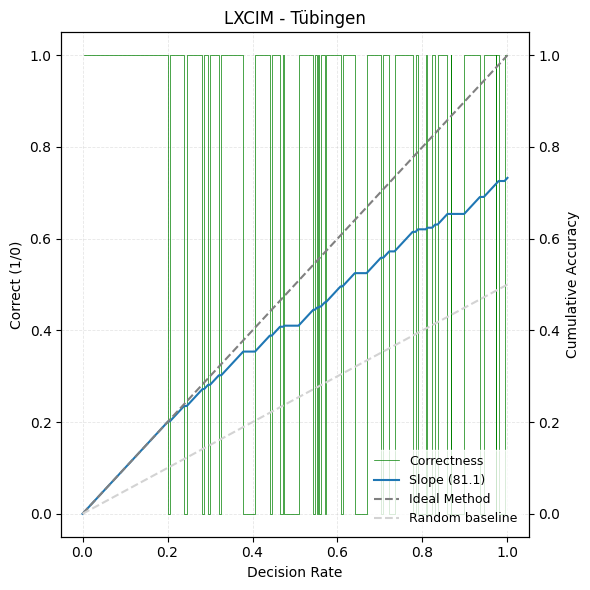

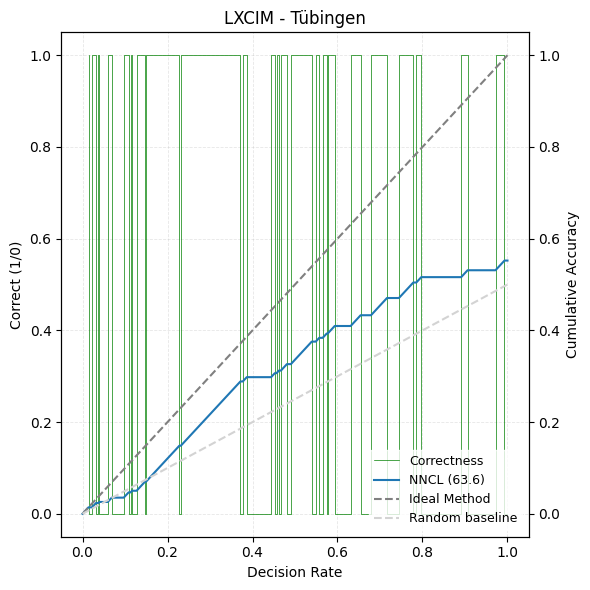

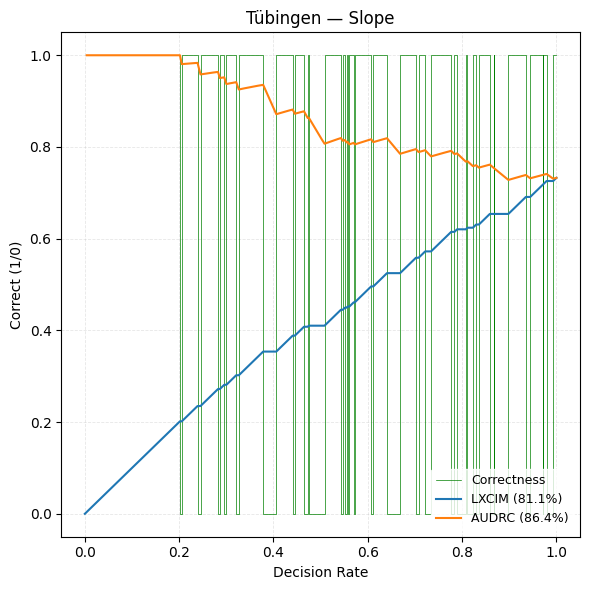

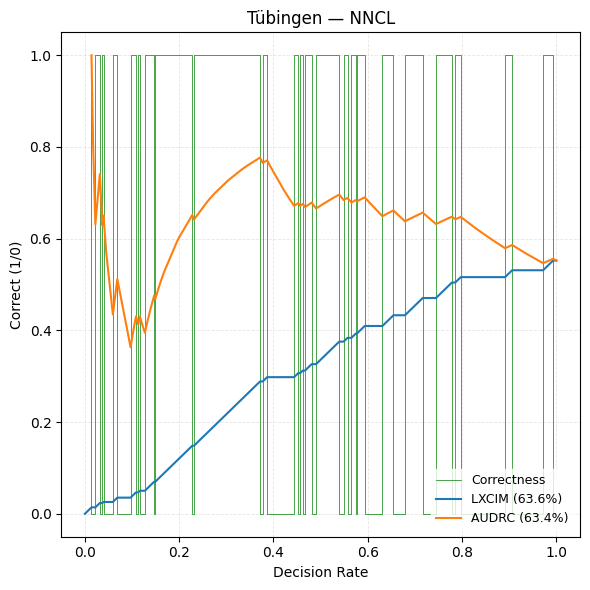

In [25]:
#Figure 3: AUDRC curves and comparison for both Slope and NNCL on the Tuebingen dataset

plot_with_correctness("Slope","Tuebingen")
plot_with_correctness("NNCL","Tuebingen")

plot_both_with_correctness("Slope","Tuebingen")
plot_both_with_correctness("NNCL","Tuebingen")

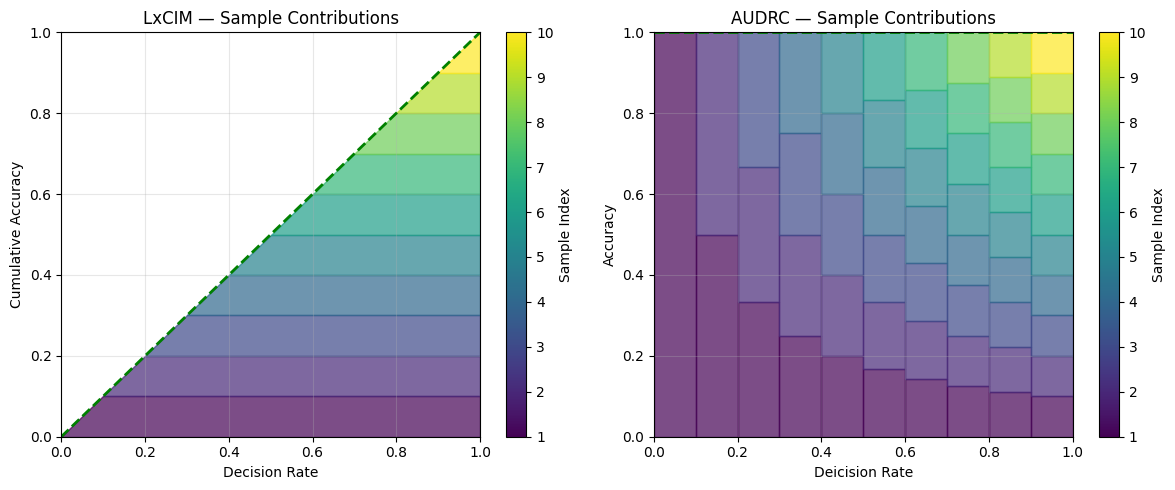

In [29]:
#Figure 4: Relative importance of confidence in LxCIM and AUDRC


# === Parameters ===
N = 10
colors = plt.cm.viridis(np.linspace(0, 1, N))

# === Coverage for triangle ===
x_fine = np.linspace(0, 1, 500)
y_triangle = x_fine  # perfect cumulative accuracy

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# --- Left: Alameda / Tiago (triangle split into trapezoids, bottom-right area) ---
# Height boundaries for each trapezoid
y_edges = np.linspace(0, 1, N+1)

for i in range(N):
    y0 = y_edges[i]
    y1 = y_edges[i+1]

    # For area under y=x, the x-coordinates at y0 and y1
    x_left_y0 = y0
    x_right_y0 = 1
    x_left_y1 = y1
    x_right_y1 = 1

    # Trapezoid coordinates (area under the curve)
    xs = [x_left_y0, x_right_y0, x_right_y1, x_left_y1]
    ys = [y0, y0, y1, y1]

    ax1.fill(xs, ys, color=colors[i], alpha=0.7)

# Outline the perfect method
ax1.plot(x_fine, y_triangle, color='green', linestyle='--', lw=2)
ax1.set_title("LxCIM — Sample Contributions")
ax1.set_xlabel("Decision Rate")
ax1.set_ylabel("Cumulative Accuracy")
ax1.set_xlim(0,1)
ax1.set_ylim(0,1)
ax1.grid(alpha=0.3)

# Colorbar
sm1 = ScalarMappable(cmap=plt.cm.viridis, norm=plt.Normalize(vmin=1, vmax=N))
cbar1 = fig.colorbar(sm1, ax=ax1, orientation='vertical')
cbar1.set_label("Sample Index")
cbar1.set_ticks(range(1, N+1))

# --- Right: AUACC (unchanged) ---
width = 1 / N
for i in range(N):
    x0 = i * width
    x1 = (i + 1) * width
    cum_height = 0
    for j in range(i+1):
        h = 1/(i+1)
        ax2.fill_between([x0, x1], cum_height, cum_height+h, color=colors[j], alpha=0.7)
        cum_height += h

ax2.plot([0,1],[1,1], color='green', linestyle='--', lw=2)
ax2.set_title("AUDRC — Sample Contributions")
ax2.set_xlabel("Deicision Rate")
ax2.set_ylabel("Accuracy")
ax2.set_xlim(0,1)
ax2.set_ylim(0,1)
ax2.grid(alpha=0.3)

sm2 = ScalarMappable(cmap=plt.cm.viridis, norm=plt.Normalize(vmin=1, vmax=N))
cbar2 = fig.colorbar(sm2, ax=ax2, orientation='vertical')
cbar2.set_label("Sample Index")
cbar2.set_ticks(range(1, N+1))

plt.tight_layout()
save_imgs("LxCIM_AUDRC_Sample_Importance", "plots")
plt.show()

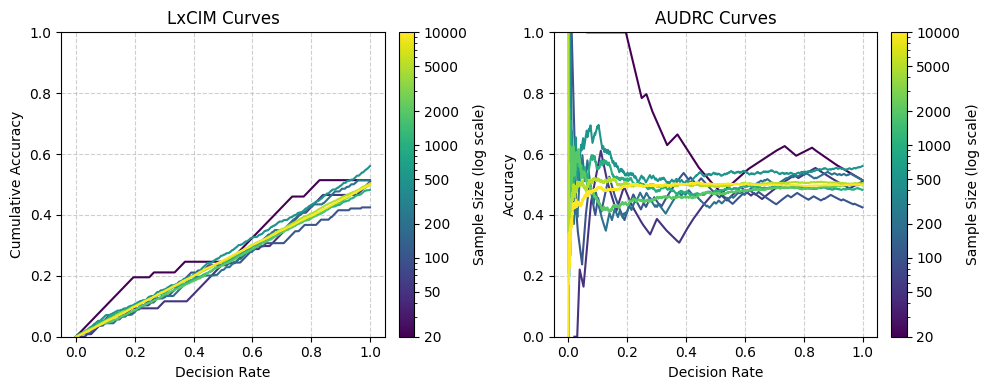

In [35]:
#Figure 5: LxCIM and AUDRC smootheness as a function of sample size

# -----------------------------
# Input sizes and setup
# -----------------------------
sizes = np.array([20, 50, 100, 200, 500, 1000, 2000, 5000, 10000])


fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# --- Plot 1: Alameda curves ---
ax1 = axes[0]
ax1.set_title("LxCIM Curves")
ax1.set_xlabel("Decision Rate")
ax1.set_ylabel("Cumulative Accuracy")
ax1.set_ylim(0, 1)
ax1.grid(True, linestyle='--', alpha=0.6)

# --- Plot 2: AUDRC curves ---
ax2 = axes[1]
ax2.set_title("AUDRC Curves")
ax2.set_xlabel("Decision Rate")
ax2.set_ylabel("Accuracy")
ax2.set_ylim(0, 1)
ax2.grid(True, linestyle='--', alpha=0.6)

# Loop over sizes
for i, size in enumerate(sizes):
    color = colors[i]

    scores = np.random.randn(size)
    weights = np.random.rand(size)

    # Alameda
    a_val, cumacc, dr = compute_lxcim(scores, weights)
    ax1.plot(dr, cumacc, color=color)

    # AUDRC
    b_val, acc, dr = compute_audrc(scores, weights)
    ax2.plot(dr, acc, color=color)

norm = LogNorm(vmin=sizes.min(), vmax=sizes.max())  # ✅ Correct usage
colors = cm.viridis(norm(sizes))
# --- Add individual colorbars inside each plot ---
for ax in [ax1, ax2]:
    sm = plt.cm.ScalarMappable(cmap=cm.viridis, norm=norm)
    cbar = plt.colorbar(sm, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("Sample Size (log scale)")
    cbar.set_ticks(sizes)
    cbar.ax.set_yticklabels([str(s) for s in sizes])

plt.tight_layout()
save_imgs("LxCIM_AUDRC_Sample_Importance", "plots")
plt.show()


In [2]:
#Table 1: LxCIM, accuracy, AUROC and AUDRC results on the Tuebingen dataset for all implemented methods

evaluate_tuebingen(methods=all_methods,metrics=["LxCIM","accuracy","AUROC","AUDRC"])
construct_table(methods=all_methods, datasets=["Tuebingen"], metrics=["LxCIM","accuracy","AUROC","AUDRC"], include_variations=True, table_title="LxCIM paper- Table 1")

✅ Evaluation complete. Results written to results/results.csv

RESULT TABLE
| Method   | Parameters                                       | Dataset   |   LxCIM (%) |   Accuracy (%) |   AUROC (%) |   AUDRC (%) |
|----------|--------------------------------------------------|-----------|-------------|----------------|-------------|-------------|
| ANM      |                                                  | Tübingen  |        61.7 |           60.4 |        59.5 |        62.9 |
| bQCD     |                                                  | Tübingen  |        71.1 |           69.6 |        72.6 |        70.1 |
| CAM      |                                                  | Tübingen  |        45.7 |           52.3 |        48.9 |        43.1 |
| CDCI     |                                                  | Tübingen  |        59.4 |           61.5 |        59.9 |        55   |
| CDS      |                                                  | Tübingen  |        60.2 |           60.5 |        

,Method,Parameters,Dataset,LxCIM (%),Accuracy (%),AUROC (%),AUDRC (%)
0,ANM,,Tübingen,61.7,60.4,59.5,62.9
15,bQCD,,Tübingen,71.1,69.6,72.6,70.1
1,CAM,,Tübingen,45.7,52.3,48.9,43.1
2,CDCI,,Tübingen,59.4,61.5,59.9,55.0
3,CDS,,Tübingen,60.2,60.5,62.6,57.8
4,CGNN,"{""nruns"": 3,""test_epochs"": 2,""train_epochs"": 10}",Tübingen,62.8,61.5,62.6,69.6
5,FOM,,Tübingen,46.1,45.5,46.5,40.9
6,HECI,,Tübingen,74.1,70.5,73.7,79.2
7,IGCI,,Tübingen,70.0,60.9,72.4,73.3
8,LCube,,Tübingen,62.4,58.9,63.3,70.1
